In [65]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd
from scipy.stats import norm
from sklearn.mixture import GaussianMixture as GM 

* Let's define 0 = clear, 1 = cloudy

In [ ]:
def nextstep_weather (today):
    x = rd.random()
    if today == 0: 
        if x <= 0.1: return 1
        else: return 0
    if today == 1:
        if x <= 0.5: return 1
        else: return 0

In [ ]:
init = 1
N = int(5e4)

chain = np.zeros(N+1)
chain[0] = init
for i in range(N):
    tomorrow = nextstep_weather(chain[i])
    chain[i+1] = tomorrow

cum_frac = np.zeros((2, N+1))
for i in range(len(chain)):
    if chain[i] == 0: cum_frac[0,i] = (cum_frac[0,i-1]+1)
    else: cum_frac[0,i] = cum_frac[0,i-1]
    if chain[i] == 1: cum_frac[1,i] = cum_frac[1,i-1]+1
    else: cum_frac[1,i] = cum_frac[1,i-1]

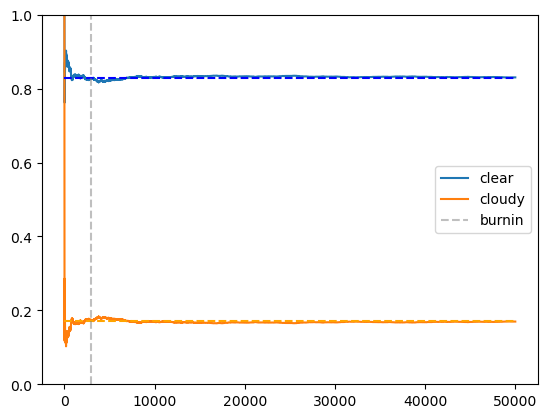

In [108]:
days = np.linspace(0, N, N+1)
burnin=3000

plt.plot(days[1:], cum_frac[0,1:]/days[1:], label='clear')
plt.plot(days[1:], cum_frac[1,1:]/days[1:], label='cloudy')
plt.plot([0,N],[0.83, 0.83], ls='dashed', c='blue')
plt.plot([0,N],[0.17, 0.17], ls='dashed', c='orange')
plt.vlines(burnin, ymin=0, ymax=2, color='gray', ls='dashed', alpha=0.5, label='burnin')
plt.ylim((0,1))
plt.legend()

0.0027666314622894644
0.002807659981977247


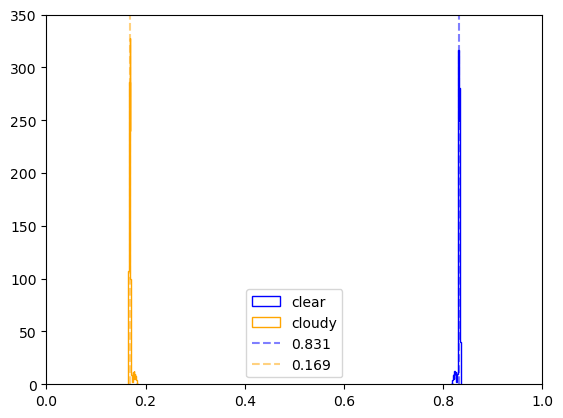

In [112]:
print(np.std(cum_frac[0,burnin:]/days[burnin:]))
print(np.std(cum_frac[1,burnin:]/days[burnin:]))

plt.hist(cum_frac[0,burnin:]/days[burnin:], histtype='step', color='blue', label='clear', density=True, bins=25)
plt.hist(cum_frac[1,burnin:]/days[burnin:], histtype='step', color='orange', label='cloudy', density=True, bins=25)
plt.vlines(np.mean(cum_frac[0,burnin:]/days[burnin:]), ymin=0, ymax=1000, color='blue', ls='dashed', alpha=0.5, label=f"{np.mean(cum_frac[0,burnin:]/days[burnin:]):.3f}")
plt.vlines(np.mean(cum_frac[1,burnin:]/days[burnin:]), ymin=0, ymax=1000, color='orange', ls='dashed', alpha=0.5, label=f"{np.mean(cum_frac[1,burnin:]/days[burnin:]):.3f}")
plt.ylim((0,350))
plt.xlim((0,1))
plt.legend()
plt.show()